In [1]:
import numpy as np
import torch
from flonacomldft.gaussian_utils import MoG
import matplotlib.pyplot as plt

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sep = 2.
means = [torch.tensor([-sep, 0]), torch.tensor([sep, 0])]
covars = [2e-1 * torch.eye(2),  2e-1 * torch.eye(2)]

target = MoG(means, covars, weights=[0.2, 0.8])

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/torch/functional.py:568: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2228.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


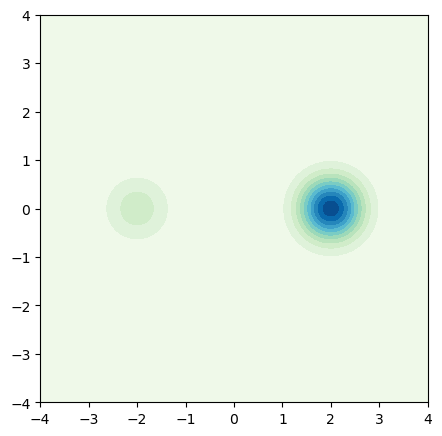

In [3]:
lims = {'x_min':-2 * sep, 'x_max':2 * sep, 'y_min':-2 * sep, 'y_max':2 * sep}
device = 'cpu'

def set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=None, lims=lims):
    
    x_range = torch.linspace(lims['x_min'], lims['x_max'], n_points, device=device)

    if lims['y_min'] is None:
        y_range = x_range.clone()
    else:
        y_range = torch.linspace(lims['y_min'], lims['y_max'], n_points, device=device)

    grid = torch.meshgrid(x_range, y_range)
    xys = torch.stack(grid).reshape(2, n_points ** 2).T.to(device)

    Us_target = target_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

    if ax is None:
        plt.figure()
    else:
        plt.sca(ax)
    #plt.axis('off')

    plt.contourf(x_range, y_range, np.exp(Us_target)
    # np.log( - Us_target + Us_target.max() + 1)
    , 10, cmap='GnBu')
    ax.set_aspect('equal')

    if prop_log_prob is not None:
        Us_prop = prop_log_prob(xys).reshape(n_points, n_points).T.detach().cpu().numpy()

        plt.contour(x_range, y_range, np.exp(Us_prop), 10, colors='k', linestyles=':', alpha=0.5)


plt.figure(figsize=(5,7))
ax = plt.subplot(1,1,1)
set_plot(ax)

In [4]:
from flonacomldft.models.real_nvp import RealNVP_MLP
from flonacomldft.train_flow_from_data import train_flow

In [5]:
#flow

n_blocks = 4
hidden_dim = 64
hidden_depth = 4

model = RealNVP_MLP(2,
                    n_blocks=n_blocks,
                    block_depth=1,
                    init_weight_scale=1e-3,
                    base_cov=None,
                    hidden_dim=hidden_dim,
                    hidden_depth=hidden_depth,
                    device=device,
                    )

In [6]:
# dataset
n_samples = 10000

target_samples = target.sample(n_samples)
target_us = target.U(target_samples)
id_mode = torch.zeros(n_samples)

dataset = torch.cat([target_samples.T, target_us.reshape(1, -1), id_mode.reshape(1, -1)]).T

/home/amolina/anaconda3/envs/ml-dft/lib/python3.10/site-packages/torch/distributions/distribution.py:159: UserWarning: sample_n will be deprecated. Use .sample((n,)) instead
  warnings.warn('sample_n will be deprecated. Use .sample((n,)) instead', UserWarning)


In [7]:
train = dataset[:int(n_samples*0.8)]
test = dataset[int(n_samples*0.8):]

In [8]:
flow_dic = train_flow(
    model,
    train,
    test,
    dim=2,
    n_iter=50,
    lr=1e-3,
    use_scheduler=False,
    step_schedule=int(100000/10),
    save_splits=10,
    grad_clip=1e4,
    with_tqdm=False,
)

t=0.0e+00 	 loss: 4.06	Gd: 2e+00	lr: 1.00e-03
t=5.0e+00 	 loss: 4.03	Gd: 2e+00	lr: 1.00e-03
t=1.0e+01 	 loss: 3.99	Gd: 2e+00	lr: 1.00e-03
t=1.5e+01 	 loss: 3.93	Gd: 2e+00	lr: 1.00e-03
t=2.0e+01 	 loss: 3.85	Gd: 2e+00	lr: 1.00e-03
t=2.5e+01 	 loss: 3.73	Gd: 2e+00	lr: 1.00e-03
t=3.0e+01 	 loss: 3.56	Gd: 1e+00	lr: 1.00e-03
t=3.5e+01 	 loss: 3.36	Gd: 1e+00	lr: 1.00e-03
t=4.0e+01 	 loss: 3.12	Gd: 1e+00	lr: 1.00e-03
t=4.5e+01 	 loss: 2.89	Gd: 9e-01	lr: 1.00e-03


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


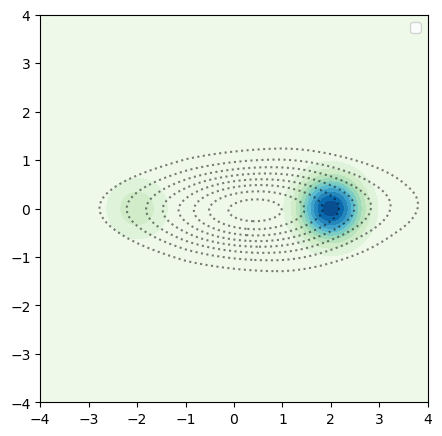

In [9]:
fig, ax = plt.subplots(1,1, figsize=(5,7))
flowlogprob = lambda x: -flow_dic['model'].nll(x)
set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=flowlogprob, lims=lims)

plt.legend()

In [10]:
kb = 8.617333262e-5
T = 300
beta = 1 / (kb * T)
target_energy = lambda x: target.U(x) / beta

In [11]:
from flonacomldft.models.mixture import Mixture
from flonacomldft.internal_coordinates import join_data
from flonacomldft.sampling import run_metropolis
import copy

In [12]:
def Transpose(x):
    return x.permute(*torch.arange(x.ndim - 1, -1, -1))

In [13]:
def full_adaptative_sampling(
        flow_init_train,
        flow_init_test,
        init_mcmc,
        dict_flows_init,
        dict_mlps_init,
        flow_hyperparams,
        n_chains,
        n_steps,
        n_runs,
        dim=12,
        energy_type='mlp',
        mixture=False,
        T=300
        ):

    isomers = torch.unique(flow_init_train[:, dim+1])

    xs_for_flows_train = [ flow_init_train[flow_init_train[:, dim+1] == isomer] for isomer in isomers ]
    xs_for_flows_test = [ flow_init_test[flow_init_test[:, dim+1] == isomer] for isomer in isomers ]

    print('init shape', xs_for_flows_train[0].shape)

    flow_models = dict_flows_init['model']
    mlp_models = dict_mlps_init['model']

    dict_flows_training = [copy.deepcopy(dict_flows_init), ]

    mcmc_runs = []

    xs = []
    us = []
    accs = []
    isomers = []
    
    init = init_mcmc

    #init = xs_for_flows_test[0][:n_chains]

    for i in range(n_runs):

        weights = torch.tensor([0.5, 0.5]).detach()
        mixture_model = dict_flows_training[i]['model']

        mcmc_run = run_metropolis(
            model=mixture_model,
            init=init,
            n_chains=n_chains,
            n_steps=n_steps,
            id_run=i,
            energy_type=energy_type,
            mlp_models=mlp_models,
            mixture=mixture,
            dim=dim,
            )
        
        mcmc_runs.append(mcmc_run)

        xs.append(mcmc_run["xs"])
        us.append(mcmc_run["us"])
        accs.append(mcmc_run["accs"])
        isomers.append(mcmc_run["isomers"])

        init = join_data(xs[i][-1].clone(), us[i][-1].clone(), isomers[i][-1].clone())

        #TODO: Chech size of xs_for_flows_train

        chains_flatten = Transpose(
            torch.cat(
                (
                    Transpose(xs[i].clone()),
                    Transpose(us[i].clone().reshape(n_steps, n_chains, 1)),
                    Transpose(isomers[i].clone().reshape(n_steps, n_chains, 1)),
                ),
                dim=0,
            )
        )

        chains_flatten = chains_flatten.reshape(n_steps * n_chains, chains_flatten.shape[-1])

        mask_flow = chains_flatten[:, -1].bool()
        xs_from_chains = chains_flatten[~mask_flow]

        if xs_from_chains.nelement() != 0:

            # extend data set for flow training
            xs_for_flows_train[0] = torch.cat(
                (xs_for_flows_train[0].clone(), xs_from_chains.clone())
            )

            print('shape', i+1, xs_for_flows_train[0].shape)

            #add mlps
            dict_new_flow = train_flow(
                dict_flows_training[i]['model'],
                xs_for_flows_train[0],
                xs_for_flows_test[0],
                #mlp_model=get_models(dict_mlps_training[-1])[0],
                **flow_hyperparams[0],
                dim=2
                )
            
            dict_flows_training.append(copy.deepcopy(dict_new_flow))
            
        else:
            dict_new_flow_is0 = dict_flows_training[i][0]


    return dict_flows_training, mcmc_runs, xs, us, accs, isomers


In [14]:
mlp_dic = {'model': target_energy}

In [15]:
#! rm -r save_models

In [16]:
flow_hyperparams = {'n_iter': 100,
    'lr': 1e-3,
    'use_scheduler': False,
    'step_schedule': 100,
    'save_splits': 10,
    'grad_clip': 1e4}


In [17]:
n_chains = 25

init_samples = target.sample(n_chains)
init_us = target.U(init_samples)
init_id_mode = torch.zeros(n_chains)

init_mcmc = torch.cat([init_samples.T, init_us.reshape(1, -1), init_id_mode.reshape(1, -1)]).T

In [18]:
_ = full_adaptative_sampling(train, 
                         test,
                         init_mcmc, 
                         dim=2,
                         dict_flows_init=flow_dic,
                         dict_mlps_init=mlp_dic,
                         mixture=False,
                         flow_hyperparams=[flow_hyperparams],
                         n_runs=6,
                         n_chains=n_chains,
                         n_steps=50,
                        )

init shape torch.Size([8000, 4])
step: 0 	 acc: 1.00
step: 10 	 acc: 0.24
step: 20 	 acc: 0.32
step: 30 	 acc: 0.32
step: 40 	 acc: 0.36
shape 1 torch.Size([9250, 4])
t=0.0e+00 	 loss: 2.71	Gd: 6e-01	lr: 1.00e-03
t=1.0e+01 	 loss: 2.57	Gd: 2e-01	lr: 1.00e-03
t=2.0e+01 	 loss: 2.55	Gd: 1e-01	lr: 1.00e-03
t=3.0e+01 	 loss: 2.55	Gd: 5e-02	lr: 1.00e-03
t=4.0e+01 	 loss: 2.55	Gd: 6e-02	lr: 1.00e-03
t=5.0e+01 	 loss: 2.54	Gd: 1e-02	lr: 1.00e-03
t=6.0e+01 	 loss: 2.54	Gd: 2e-02	lr: 1.00e-03
t=7.0e+01 	 loss: 2.54	Gd: 1e-02	lr: 1.00e-03
t=8.0e+01 	 loss: 2.54	Gd: 8e-03	lr: 1.00e-03
t=9.0e+01 	 loss: 2.54	Gd: 1e-02	lr: 1.00e-03
step: 0 	 acc: 0.44
step: 10 	 acc: 0.24
step: 20 	 acc: 0.40
step: 30 	 acc: 0.32
step: 40 	 acc: 0.36
shape 2 torch.Size([10500, 4])
t=0.0e+00 	 loss: 2.55	Gd: 2e-02	lr: 1.00e-03
t=1.0e+01 	 loss: 2.55	Gd: 2e-02	lr: 1.00e-03
t=2.0e+01 	 loss: 2.54	Gd: 4e-02	lr: 1.00e-03
t=3.0e+01 	 loss: 2.52	Gd: 6e-02	lr: 1.00e-03
t=4.0e+01 	 loss: 2.50	Gd: 7e-02	lr: 1.00e-03
t=5.0e+0

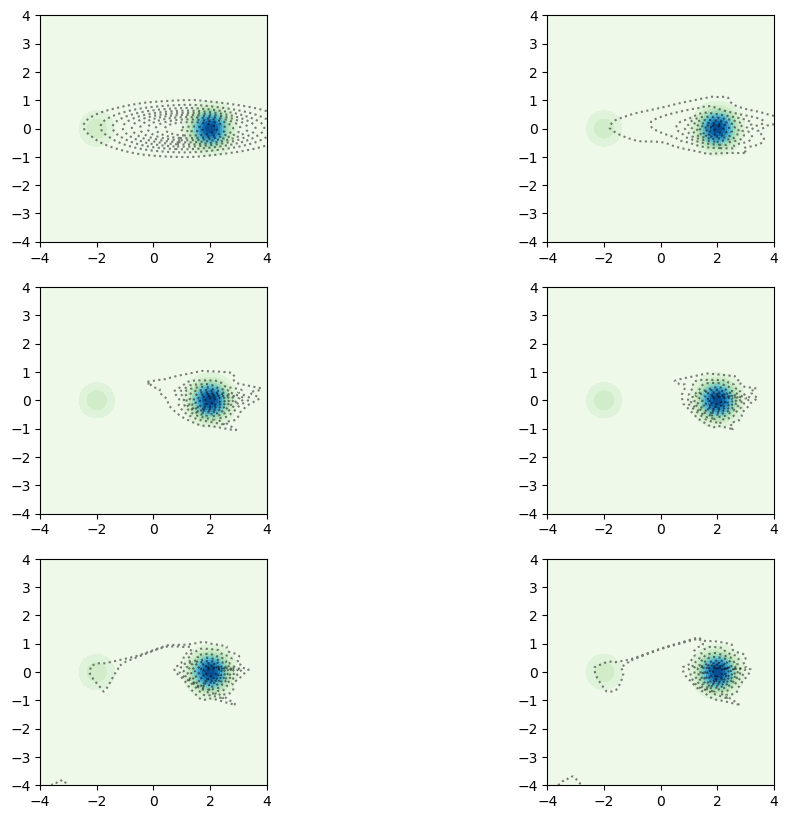

In [19]:
fig, axs = plt.subplots(3, 2, figsize=(12,10))
axs = axs.ravel()
for ax, i in zip(axs, list(range(6))):
    flowlogprob = lambda x: -_[0][i]['model'].nll(x)
    set_plot(ax, n_points=1000, target_log_prob=target.log_prob, prop_log_prob=flowlogprob, lims=lims)

    #plt.legend()

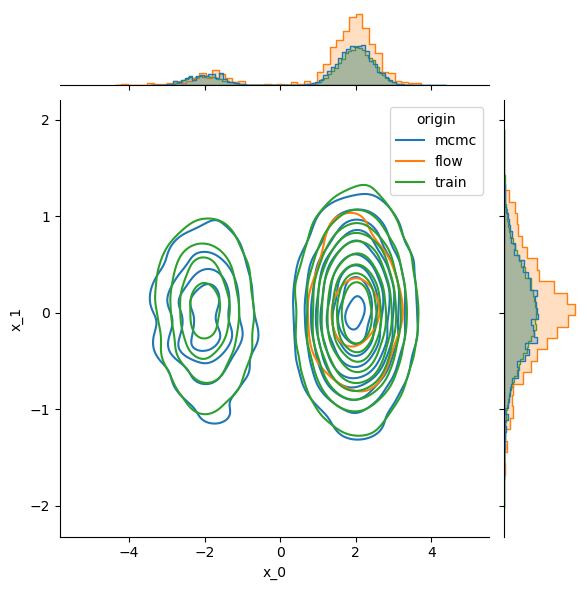

In [20]:
xs = torch.stack(_[2]).squeeze().reshape(-1, 2)
flow_dic = _[0][-1]
flow_samples = flow_dic['model'].sample(1000) 

import seaborn as sns
import pandas as pd

datas = [
            xs.view(-1,2).detach().numpy(), 
            flow_samples.detach().numpy(),
            train.detach().numpy()
]
labels = ['mcmc', 'flow', 'train']

frames = []
for d, l in zip(datas, labels):
    df = pd.DataFrame(
        {"x_{:d}".format(0): d[:,0], "x_{:d}".format(1): d[:, 1]}
    )
    df["origin"] = l
    frames.append(df)

dfs = pd.concat(frames, ignore_index=True)
g = sns.JointGrid(
    data=dfs, x="x_{:d}".format(0), y="x_{:d}".format(1), hue="origin"
)
g.plot_joint(sns.kdeplot)
g.plot_marginals(sns.histplot, element="step", fill=True, stat='probability', common_bins=False, common_norm=False)
